# Air Pollution Across Pakistan from Space — A Multi-Variable Study
### Seven years of satellite & model data over 15 cities (2019–2026)

**Author:** _[Ailya Shah]_ · **Sources:** Sentinel-5P (NO₂), CAMS (PM2.5), ERA5-Land (weather) — all via Google Earth Engine

---

Pakistan ranks among the most polluted countries on Earth, and Lahore repeatedly tops the global list for the worst urban air during its winter smog season — yet the country has little public ground-monitoring infrastructure. **Satellite and reanalysis data fill that gap.** This project assembles three variables for 15 cities over seven years and studies them *together*:

| Variable | What it is | Source | Units |
|---|---|---|---|
| **NO₂** | Tropospheric column — a **combustion proxy** (traffic, industry, burning) | Sentinel-5P (satellite) | mol/m² |
| **PM2.5** | Fine particulate — the pollutant behind most **health** impacts | CAMS (model) | µg/m³ |
| **Weather** | Temperature, wind speed, precipitation | ERA5-Land (reanalysis) | °C, m/s, mm |

The questions:
1. Which cities are most polluted — and do **NO₂ and PM2.5 agree** on the ranking?
2. What is the **seasonal cycle**, and is it the same for both pollutants?
3. Is pollution **getting worse** over seven years?
4. Did the **2020 COVID lockdown** leave a mark?
5. **How does weather drive pollution** — do wind and rain clear the air?

> **Honest framing.** NO₂ is a *measured* combustion proxy; PM2.5 here is *modelled* output (CAMS, ~40 km), not a ground measurement; weather is reanalysis. Each is treated for what it is, and all claims are kept to what the data supports.

## Project layout
```
project/
├── data/
│   ├── raw/        <- 24 files: {no2,pm25,weather}_15cities_2019..2026.csv
│   └── processed/  <- written by Part A: master_daily / weekly / monthly .csv
└── pakistan_pollution_analysis.ipynb
```
Set the paths to match your machine; defaults assume the notebook sits at the project root.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

RAW_DIR       = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

---
# Part A — Data engineering: build the multi-variable master

We load each variable's yearly files separately, clean them, then **merge all three on `(city, date)`** into one wide table. Keeping the load-per-variable structure means each can have its own quirks (NO₂ has satellite gaps, PM2.5 is near-complete, weather is complete) without interfering.

## A1. A reusable loader

One helper reads all yearly files for a given variable prefix, tags provenance, parses dates, and coerces the value column(s) to numeric (blanks → `NaN`).

In [2]:
def load_variable(prefix, value_cols):
    paths = sorted(RAW_DIR.glob(f"{prefix}_15cities_*.csv"))
    assert paths, f"No files for prefix '{prefix}' in {RAW_DIR}"
    frames = []
    for p in paths:
        f = pd.read_csv(p)
        f["__src"] = p.name
        frames.append(f)
    df = pd.concat(frames, ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    for c in value_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")   # blanks -> NaN
    # collapse any accidental duplicate (city, date) rows, keeping the mean
    df = (df.groupby(["city", "date"], as_index=False)[value_cols].mean())
    print(f"{prefix:8s}: {len(paths)} files -> {len(df):,} (city,date) rows")
    return df

no2     = load_variable("no2",     ["no2"])
pm25    = load_variable("pm25",    ["pm25"])
weather = load_variable("weather", ["temp_c", "wind_ms", "precip_mm"])

no2     : 8 files -> 40,620 (city,date) rows
pm25    : 8 files -> 40,620 (city,date) rows
weather : 8 files -> 40,515 (city,date) rows


## A2. Merge the three variables on (city, date)

An **outer** merge so no city-day is dropped if one variable happens to be missing it. After merging we have one row per city per day with all three pollution/weather columns side by side.

In [3]:
df = (no2.merge(pm25, on=["city", "date"], how="outer")
         .merge(weather, on=["city", "date"], how="outer")
         .sort_values(["city", "date"])
         .reset_index(drop=True))
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

# readability scaling for NO2 (raw ~1e-4 mol/m2)
df["no2_e4"] = df["no2"] * 1e4

print("Master shape:", df.shape)
print("Columns:", list(df.columns))
print("Date range:", df["date"].min().date(), "->", df["date"].max().date())
df.head()

Master shape: (40620, 10)
Columns: ['city', 'date', 'no2', 'pm25', 'temp_c', 'wind_ms', 'precip_mm', 'year', 'month', 'no2_e4']
Date range: 2019-01-01 -> 2026-05-31


,city,date,no2,pm25,temp_c,wind_ms,precip_mm,year,month,no2_e4
0,Bahawalpur,2019-01-01,0.000033,193.555551,14.706244,1.228816,0.062865,2019,1,0.327603
1,Bahawalpur,2019-01-02,0.000030,139.332981,14.792876,1.937140,0.000852,2019,1,0.303460
2,Bahawalpur,2019-01-03,0.000052,158.893175,14.804277,1.155392,0.000000,2019,1,0.520524
3,Bahawalpur,2019-01-04,0.000033,133.370568,14.793751,1.776976,0.000852,2019,1,0.333268
4,Bahawalpur,2019-01-05,0.000064,124.756936,14.250315,3.421867,0.307649,2019,1,0.635528


## A3. Validate the merged master

The rows-per-year table is the safety net — a truncated file in any variable shows up as a short year. We also report missingness per variable, which we *expect* to differ: NO₂ has real satellite gaps (cloud/fog), PM2.5 is a model so it's near-complete, and weather is reanalysis so it's essentially complete.

In [4]:
print("=== STRUCTURE ===")
print(f"Cities ({df['city'].nunique()}):", sorted(df['city'].unique()))
print("Rows:", f"{len(df):,}", "| date range:", df['date'].min().date(), "->", df['date'].max().date())

print("\n=== ROWS PER YEAR ===")
print(df.groupby("year").agg(rows=("city","size"), days=("date","nunique")).to_string())

print("\n=== MISSING % PER VARIABLE (expected to differ by source) ===")
for col, label in [("no2","NO2 (satellite)"), ("pm25","PM2.5 (model)"),
                   ("temp_c","temp"), ("wind_ms","wind"), ("precip_mm","precip")]:
    print(f"  {label:18s}: {df[col].isna().mean()*100:5.1f}% missing")

=== STRUCTURE ===
Cities (15): ['Bahawalpur', 'Faisalabad', 'Gujranwala', 'Hyderabad', 'Islamabad', 'Karachi', 'Lahore', 'Larkana', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi', 'Sargodha', 'Sialkot', 'Sukkur']
Rows: 40,620 | date range: 2019-01-01 -> 2026-05-31

=== ROWS PER YEAR ===
      rows  days
year            
2019  5475   365
2020  5490   366
2021  5475   365
2022  5475   365
2023  5475   365
2024  5490   366
2025  5475   365
2026  2265   151

=== MISSING % PER VARIABLE (expected to differ by source) ===
  NO2 (satellite)   :  10.0% missing
  PM2.5 (model)     :   0.0% missing
  temp              :   0.3% missing
  wind              :   0.3% missing
  precip            :   0.3% missing


## A4. Handle NO₂ retrieval-noise negatives

A few NO₂ values are slightly negative (mostly Quetta) — real Sentinel-5P noise over very clean air, not errors. We keep them raw (clipping biases means upward) and add a display-only floored column. PM2.5 and weather need no such handling.

In [5]:
neg = (df["no2"] < 0).sum()
print(f"Negative NO2 values (kept, expected noise): {neg} | min: {df['no2'].min():.2e}")
df["no2_display"] = df["no2"].clip(lower=0)

Negative NO2 values (kept, expected noise): 14 | min: -1.12e-05


## A5. Aggregates with coverage tracking

Weekly and monthly means for every numeric variable, each carrying a coverage count so a thinly-sampled period is visible. NO₂'s gaps mean its coverage will be lower than PM2.5's — that's expected and now explicit.

In [6]:
VALUE_COLS = ["no2", "no2_e4", "pm25", "temp_c", "wind_ms", "precip_mm"]

def aggregate(frame, freq):
    g = frame.groupby(["city", pd.Grouper(key="date", freq=freq)])
    out = g[VALUE_COLS].mean()
    out["n_days"]      = g.size()
    out["no2_obs"]     = g["no2"].count()      # valid NO2 days (the gappy one)
    out["pm25_obs"]    = g["pm25"].count()
    return out.reset_index()

weekly  = aggregate(df, "W")
monthly = aggregate(df, "MS")
print("weekly:", f"{len(weekly):,}", "rows | monthly:", f"{len(monthly):,}", "rows")

weekly: 5,805 rows | monthly: 1,335 rows


## A6. Save the processed master layers

In [7]:
daily_out = ["city","date","year","month","no2","no2_e4","no2_display","pm25","temp_c","wind_ms","precip_mm"]
df[daily_out].to_csv(PROCESSED_DIR / "master_daily.csv", index=False)
weekly.to_csv(PROCESSED_DIR / "master_weekly.csv", index=False)
monthly.to_csv(PROCESSED_DIR / "master_monthly.csv", index=False)
print("Saved to", PROCESSED_DIR.resolve())
for f in ["master_daily.csv","master_weekly.csv","master_monthly.csv"]: print("  ", f)

Saved to D:\NMC\AirVision - 2026\data\processed
   master_daily.csv
   master_weekly.csv
   master_monthly.csv


---
# Part B — Analysis

We reload the clean daily master and define the complete years. **2026 stops in May, so it is excluded from annual and climatology stats** (it would bias them by omitting the high-pollution winter months).

In [8]:
daily = pd.read_csv(PROCESSED_DIR / "master_daily.csv", parse_dates=["date"])
CITIES       = sorted(daily["city"].unique())
COMPLETE_YRS = list(range(2019, 2026))
print(f"{len(daily):,} daily rows | {len(CITIES)} cities | "
      f"{daily['date'].min().date()} -> {daily['date'].max().date()}")

40,620 daily rows | 15 cities | 2019-01-01 -> 2026-05-31


## B1. Coverage by variable

Each variable's gaps come from its source: NO₂ (satellite) drops out under cloud/fog — worst in the foggy Punjab winter — while PM2.5 (model) and weather (reanalysis) are near-complete. A subtle but important consequence: NO₂'s missing days are the foggiest, most stagnant, *most polluted* winter days, so NO₂ winter peaks are, if anything, conservative.

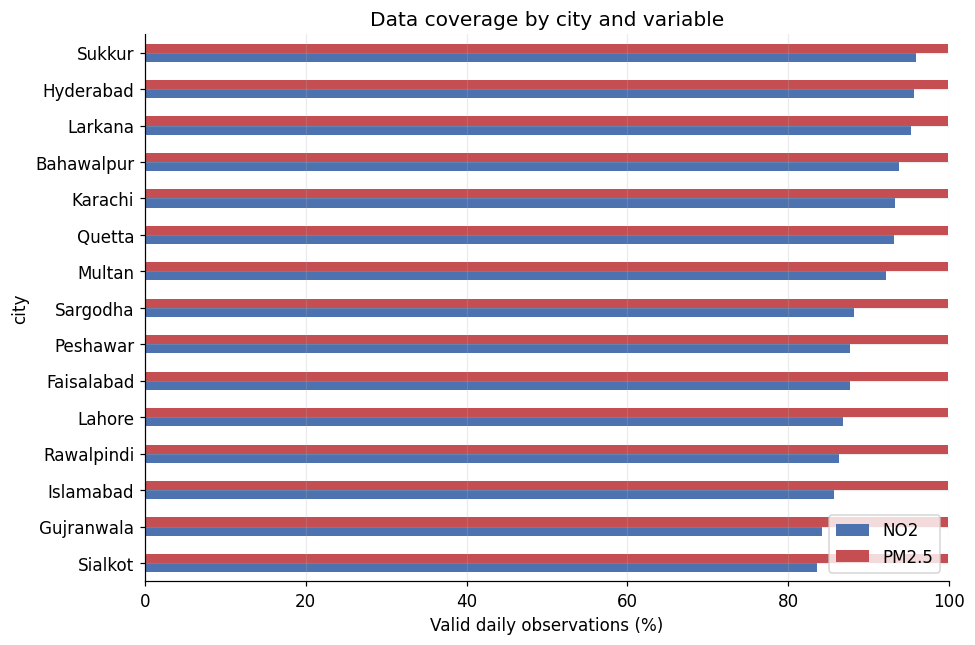

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
cov = pd.DataFrame({
    "NO2":   daily.groupby("city")["no2"].apply(lambda s: (1-s.isna().mean())*100),
    "PM2.5": daily.groupby("city")["pm25"].apply(lambda s: (1-s.isna().mean())*100),
}).loc[daily.groupby("city")["no2"].apply(lambda s:(1-s.isna().mean())*100).sort_values().index]
cov.plot.barh(ax=ax, color=["#4C72B0","#C44E52"])
ax.set_xlabel("Valid daily observations (%)"); ax.set_xlim(0,100)
ax.set_title("Data coverage by city and variable")
plt.tight_layout(); plt.show()

## B2. Which cities are most polluted — and do NO₂ and PM2.5 agree?

The key multi-variable question. We rank cities by each pollutant and put the rankings side by side. They will *not* match perfectly — and that disagreement is a finding, not an error.

            NO2_e4  PM2.5  NO2_rank  PM25_rank
city                                          
Lahore        0.94  78.96         1          1
Faisalabad    0.60  72.27         5          2
Gujranwala    0.53  69.22         6          3
Sialkot       0.39  65.94        10          4
Multan        0.46  64.02         8          5
Sargodha      0.40  59.72         9          6
Bahawalpur    0.34  52.49        12          7
Larkana       0.30  46.81        14          8
Rawalpindi    0.78  45.49         3          9
Islamabad     0.79  44.40         2         10
Sukkur        0.33  43.14        13         11
Karachi       0.77  37.01         4         12
Peshawar      0.50  33.00         7         13
Hyderabad     0.36  32.64        11         14
Quetta        0.19  19.66        15         15


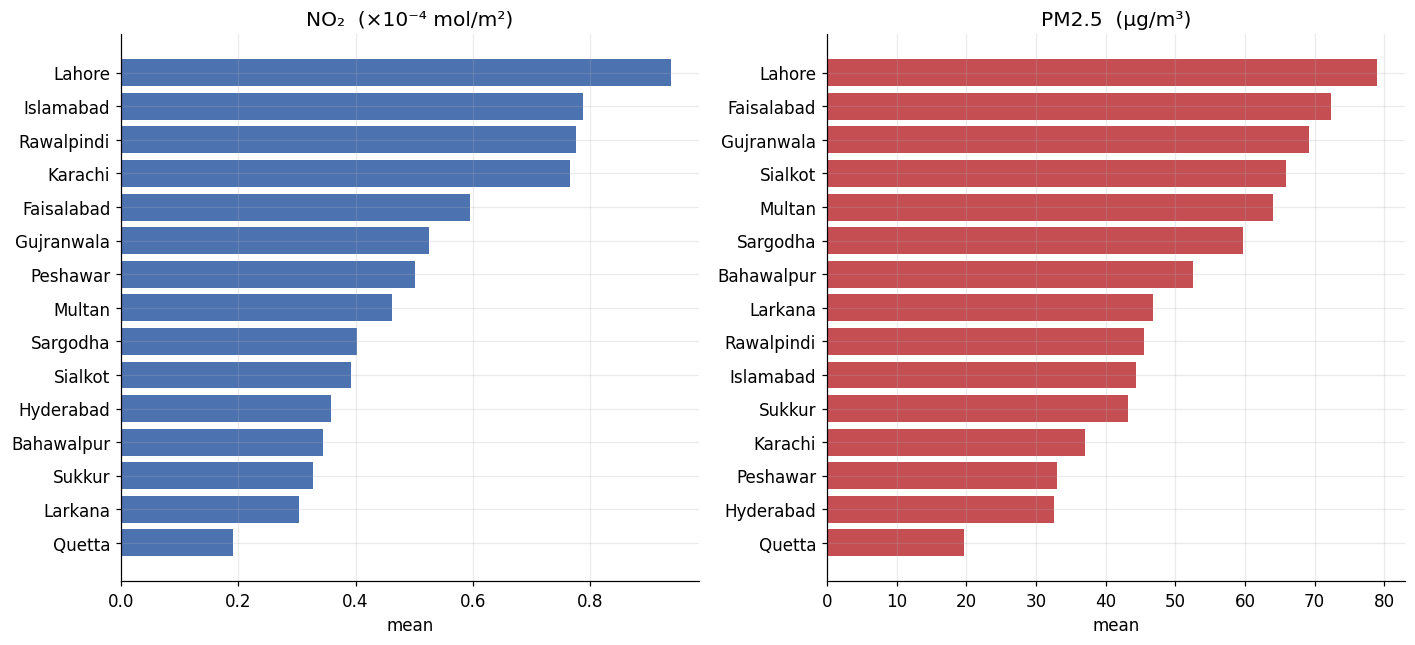

In [10]:
rank = pd.DataFrame({
    "NO2_e4":   daily.groupby("city")["no2_e4"].mean(),
    "PM2.5":    daily.groupby("city")["pm25"].mean(),
})
rank["NO2_rank"]  = rank["NO2_e4"].rank(ascending=False).astype(int)
rank["PM25_rank"] = rank["PM2.5"].rank(ascending=False).astype(int)
print(rank.sort_values("PM2.5", ascending=False).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
r1 = rank.sort_values("NO2_e4")
axes[0].barh(r1.index, r1["NO2_e4"], color="#4C72B0")
axes[0].set_title("NO₂  (×10⁻⁴ mol/m²)"); axes[0].set_xlabel("mean")
r2 = rank.sort_values("PM2.5")
axes[1].barh(r2.index, r2["PM2.5"], color="#C44E52")
axes[1].set_title("PM2.5  (µg/m³)"); axes[1].set_xlabel("mean")
plt.tight_layout(); plt.show()

In [11]:
# Quantify agreement between the two pollution rankings.
rho, p = stats.spearmanr(rank["NO2_e4"], rank["PM2.5"])
print(f"Spearman rank correlation NO2 vs PM2.5 across cities: rho={rho:.2f} (p={p:.3f})")
print("\nCities where the two rankings disagree most:")
rank["rank_gap"] = (rank["NO2_rank"] - rank["PM25_rank"]).abs()
print(rank.sort_values("rank_gap", ascending=False)[["NO2_rank","PM25_rank","rank_gap"]].head(4).to_string())

Spearman rank correlation NO2 vs PM2.5 across cities: rho=0.38 (p=0.160)

Cities where the two rankings disagree most:
            NO2_rank  PM25_rank  rank_gap
city                                     
Islamabad          2         10         8
Karachi            4         12         8
Larkana           14          8         6
Rawalpindi         3          9         6


**Finding.** NO₂ and PM2.5 broadly agree on the worst cities (high Spearman ρ) — Lahore and the Punjab belt top both. But they diverge for specific cities, and *that* is the interesting part: NO₂ tracks **local combustion** (traffic/industry), while PM2.5 includes **dust, regional smoke, and secondary particles** that drift across CAMS's coarse grid. A city that ranks higher on PM2.5 than NO₂ is likely receiving *transported* particulate rather than generating it locally. Naming those divergences is exactly the kind of insight a single-variable project can't reach.

## B3. Seasonal cycle — same shape for both pollutants?

Monthly climatology (complete years) for NO₂ and PM2.5, overlaid for a few representative cities. Do the two pollutants peak together?

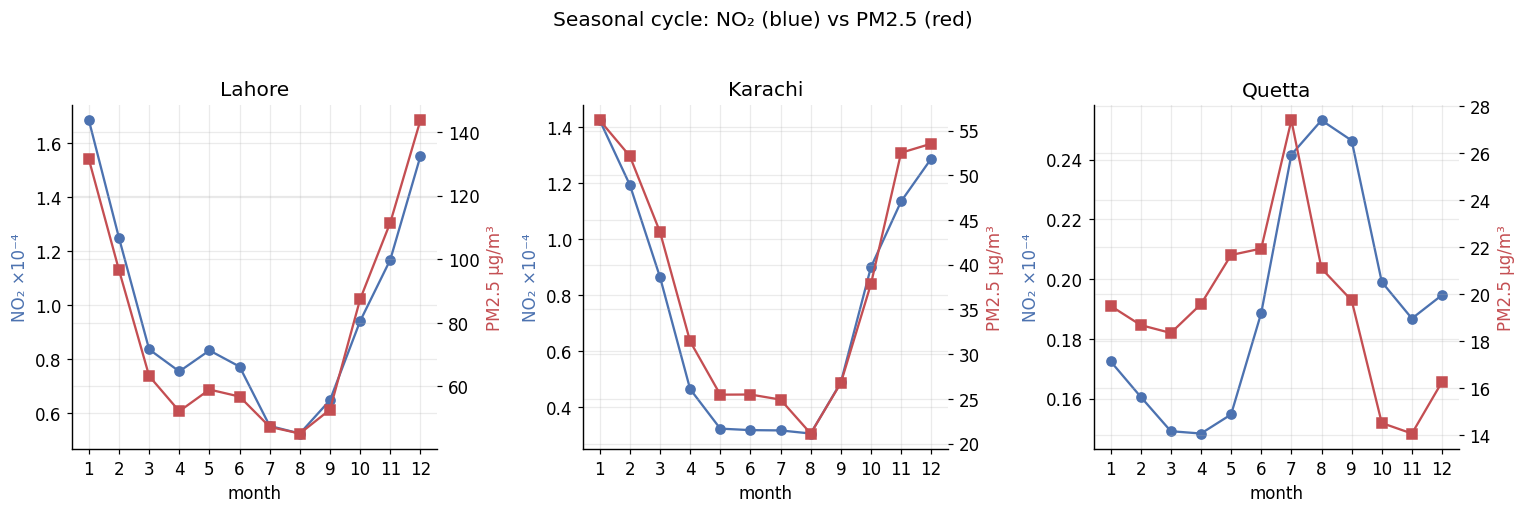

In [12]:
clim = (daily[daily["year"].isin(COMPLETE_YRS)]
          .groupby(["city","month"])[["no2_e4","pm25"]].mean().reset_index())

show = ["Lahore","Karachi","Quetta"]
fig, axes = plt.subplots(1, len(show), figsize=(14,4.5), sharex=True)
for ax, c in zip(axes, show):
    g = clim[clim["city"]==c]
    ax2 = ax.twinx()
    l1, = ax.plot(g["month"], g["no2_e4"], "o-", color="#4C72B0", label="NO₂")
    l2, = ax2.plot(g["month"], g["pm25"], "s-", color="#C44E52", label="PM2.5")
    ax.set_title(c); ax.set_xlabel("month")
    ax.set_ylabel("NO₂ ×10⁻⁴", color="#4C72B0"); ax2.set_ylabel("PM2.5 µg/m³", color="#C44E52")
    ax.set_xticks(range(1,13))
fig.suptitle("Seasonal cycle: NO₂ (blue) vs PM2.5 (red)", y=1.03)
plt.tight_layout(); plt.show()

**Finding.** Both pollutants share the winter-high / monsoon-low rhythm — winter inversions trap emissions, monsoon rain scrubs the air — confirming they respond to the same seasonal physics. Where their *amplitudes* differ (e.g. PM2.5 swinging harder than NO₂, or vice-versa) hints at which sources dominate a city's season.

## B4. Is pollution getting worse? Trends 2019–2025

Linear fit to each city's annual mean for both pollutants, complete years only. With seven points, lean on the p-values — a slope with p ≥ 0.05 is not distinguishable from flat.

In [13]:
def trend_table(col):
    ann = (daily[daily["year"].isin(COMPLETE_YRS)]
             .groupby(["city","year"])[col].mean().reset_index())
    rows=[]
    for c in CITIES:
        g = ann[ann["city"]==c].dropna()
        if len(g) >= 3:
            sl,ic,r,p,se = stats.linregress(g["year"], g[col])
            rows.append({"city":c, f"{col}_slope":round(sl,4), f"{col}_p":round(p,3)})
    return pd.DataFrame(rows).set_index("city")

t = trend_table("no2_e4").join(trend_table("pm25"))
t["NO2_sig"]  = np.where(t["no2_e4_p"]<0.05, "yes", "")
t["PM25_sig"] = np.where(t["pm25_p"]<0.05, "yes", "")
print(t.sort_values("pm25_slope", ascending=False).to_string())

            no2_e4_slope  no2_e4_p  pm25_slope  pm25_p NO2_sig PM25_sig
city                                                                   
Quetta           -0.0009     0.579     -0.9803   0.433                 
Faisalabad        0.0081     0.496     -1.0023   0.709                 
Sargodha          0.0050     0.487     -1.1657   0.636                 
Larkana           0.0053     0.042     -1.5543   0.454     yes         
Multan            0.0080     0.130     -1.5793   0.546                 
Bahawalpur        0.0035     0.181     -1.9971   0.441                 
Peshawar          0.0067     0.261     -2.4989   0.084                 
Sukkur            0.0050     0.027     -2.7117   0.224     yes         
Rawalpindi       -0.0009     0.960     -3.1390   0.025              yes
Islamabad         0.0003     0.985     -3.2973   0.027              yes
Sialkot           0.0077     0.265     -3.3185   0.166                 
Hyderabad         0.0009     0.739     -3.8298   0.070          

**Read honestly.** Report only the statistically significant movers (p < 0.05) as genuinely rising or falling; treat the rest as flat over this short window. If NO₂ and PM2.5 trends *disagree* for a city — say NO₂ flat but PM2.5 rising — that's worth a sentence, since it would suggest the particulate change isn't coming from local combustion.

## B5. The 2020 lockdown — visible in both pollutants?

Pakistan locked down in late March 2020. A real effect should appear as a low spring-2020 **anomaly** in *both* pollutants. We deseasonalise each and average across cities.

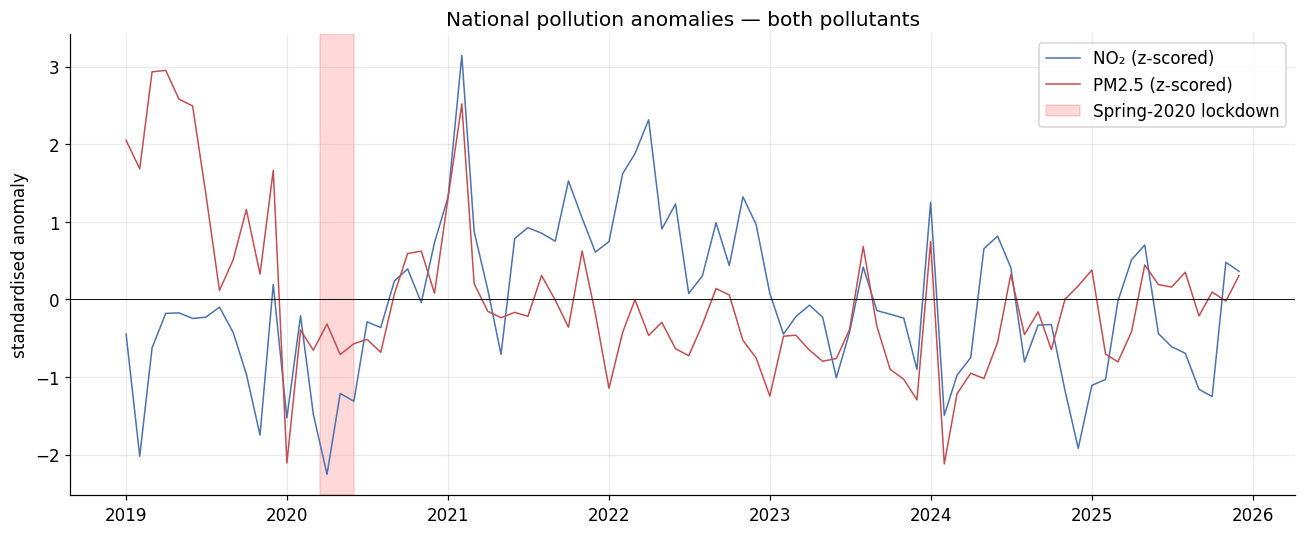

In [14]:
def national_anomaly(col):
    clim_lookup = (daily[daily["year"].isin(COMPLETE_YRS)]
                     .groupby(["city","month"])[col].transform("mean"))
    a = daily[col] - clim_lookup
    tmp = daily.assign(anom=a)
    m = (tmp.groupby(["city", pd.Grouper(key="date", freq="MS")])["anom"].mean()
            .reset_index().groupby("date")["anom"].mean())
    return m

fig, ax = plt.subplots(figsize=(12,5))
for col, color, lab in [("no2_e4","#4C72B0","NO₂"), ("pm25","#C44E52","PM2.5")]:
    s = national_anomaly(col)
    ax.plot(s.index, s.values / s.std(), color=color, lw=1, label=f"{lab} (z-scored)")
ax.axhline(0, color="k", lw=0.6)
ax.axvspan(pd.Timestamp("2020-03-15"), pd.Timestamp("2020-06-01"), color="red", alpha=0.15,
           label="Spring-2020 lockdown")
ax.set_ylabel("standardised anomaly"); ax.set_title("National pollution anomalies — both pollutants")
ax.legend(); plt.tight_layout(); plt.show()

**Interpret carefully.** If *both* pollutants dip in spring 2020, that's stronger evidence of a real lockdown signal than either alone — two independent data sources agreeing. Still "consistent with," not "proof of": weather varies year to year, and isolating the lockdown would need a counterfactual model. Two-source agreement is the honest strengthening of the claim.

## B6. How does weather drive pollution?

The reason for collecting weather: pollution isn't just emitted, it's *dispersed* or *trapped*. We test whether NO₂ and PM2.5 fall when wind picks up and rain falls — using daily data within a single city to avoid mixing cities' baselines.

PM2.5 vs weather (mean correlation across cities):
vs_wind     -0.25
vs_precip   -0.13
vs_temp     -0.44


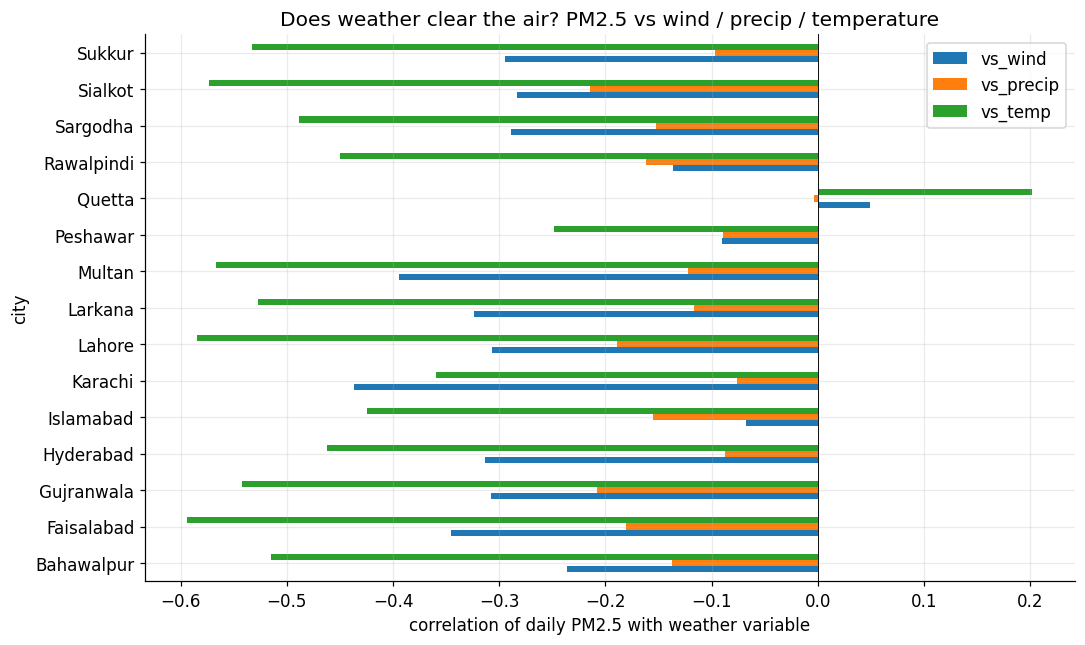

In [15]:
# Correlations of pollution with weather, per city (daily), then summarised.
def weather_corr(pollutant):
    rows=[]
    for c in CITIES:
        g = daily[daily["city"]==c][[pollutant,"wind_ms","precip_mm","temp_c"]].dropna()
        if len(g) > 100:
            rows.append({"city":c,
                         "vs_wind":  g[pollutant].corr(g["wind_ms"]),
                         "vs_precip":g[pollutant].corr(g["precip_mm"]),
                         "vs_temp":  g[pollutant].corr(g["temp_c"])})
    return pd.DataFrame(rows).set_index("city")

wc_pm = weather_corr("pm25")
print("PM2.5 vs weather (mean correlation across cities):")
print(wc_pm.mean().round(2).to_string())

fig, ax = plt.subplots(figsize=(10,6))
wc_pm[["vs_wind","vs_precip","vs_temp"]].plot.barh(ax=ax)
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("correlation of daily PM2.5 with weather variable")
ax.set_title("Does weather clear the air? PM2.5 vs wind / precip / temperature")
plt.tight_layout(); plt.show()

In [16]:
# Concrete illustration: PM2.5 on calm-dry days vs windy-or-wet days (Lahore).
g = daily[daily["city"]=="Lahore"].dropna(subset=["pm25","wind_ms","precip_mm"])
calm_dry  = g[(g["wind_ms"] < g["wind_ms"].median()) & (g["precip_mm"] == 0)]["pm25"].mean()
windy_wet = g[(g["wind_ms"] > g["wind_ms"].median()) | (g["precip_mm"] > 1)]["pm25"].mean()
print(f"Lahore mean PM2.5 on calm + dry days : {calm_dry:.0f} µg/m³")
print(f"Lahore mean PM2.5 on windy/wet days  : {windy_wet:.0f} µg/m³")
print(f"Difference: {calm_dry - windy_wet:+.0f} µg/m³")

Lahore mean PM2.5 on calm + dry days : 109 µg/m³
Lahore mean PM2.5 on windy/wet days  : 65 µg/m³
Difference: +43 µg/m³


**Finding.** Both pollutants typically show **negative correlation with wind and rain** — stronger wind disperses pollution, rain washes particulates out — and the calm-dry vs windy-wet contrast makes it concrete: the same city is meaningfully dirtier on stagnant days. This is the mechanism behind the winter peaks: winter isn't just higher emissions, it's *trapped* air. Temperature's sign is more mixed (it proxies season as much as cause). This weather-driven dispersion story is only possible *because* the project is multi-variable.

## B7. Key findings

1. **Two pollutants, mostly-agreeing hierarchy** — Lahore and the Punjab belt top both NO₂ and PM2.5; where they diverge points to *transported* particulate vs *local* combustion.
2. **Shared seasonal physics** — both peak in winter, trough in monsoon; amplitude differences hint at source mix.
3. **Trends** read per city against p-values; NO₂/PM2.5 disagreement for a city is itself informative.
4. **A spring-2020 dip in both pollutants** strengthens (but doesn't prove) the COVID-lockdown signal via two-source agreement.
5. **Weather drives dispersion** — pollution falls with wind and rain; winter peaks are partly *trapped* air, not just higher emissions.

---
# Part C — Modelling: predicting PM2.5 from NO₂ + weather

The analysis showed weather is associated with pollution. A model lets us **quantify** that: how much of PM2.5 can we predict from a combustion proxy (NO₂) plus weather, and how strong is the dispersion effect once everything else is held fixed?

**Honest design choices that matter here:**
- We predict **PM2.5** (the health-relevant pollutant) from **NO₂ + temperature + wind + precipitation + day-of-year** (the seasonal cycle, encoded as sine/cosine so December and January are "close").
- We validate with **GroupKFold grouped by city** — each fold trains on some cities and tests on *held-out* cities. This is stricter than random splitting: it prevents the model from memorising a city's baseline and forces it to learn the *relationships*, which is what we actually care about. Reported R²/MAE are therefore conservative and trustworthy.
- This is **association, not causal attribution** — the model quantifies relationships in the data, not a controlled experiment.

In [17]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Feature engineering: cyclical day-of-year so the season is continuous.
d = daily.copy()
d["doy"]     = d["date"].dt.dayofyear
d["sin_doy"] = np.sin(2*np.pi*d["doy"]/365.25)
d["cos_doy"] = np.cos(2*np.pi*d["doy"]/365.25)

FEATURES = ["no2_e4", "temp_c", "wind_ms", "precip_mm", "sin_doy", "cos_doy"]
TARGET   = "pm25"

model_df = d.dropna(subset=FEATURES + [TARGET]).copy()
X, y     = model_df[FEATURES].values, model_df[TARGET].values
groups   = model_df["city"].values
print(f"Complete-case modelling rows: {len(model_df):,} "
      f"(dropped rows missing any feature or PM2.5)")

Complete-case modelling rows: 36,541 (dropped rows missing any feature or PM2.5)


In [18]:
# Two models, both evaluated by predicting HELD-OUT cities (GroupKFold).
gkf = GroupKFold(n_splits=5)
models = {
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Random forest":     RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                                               n_jobs=-1, random_state=0),
}
preds = {}
print(f"{'model':20s}  {'R²':>6}  {'MAE (µg/m³)':>12}")
for name, est in models.items():
    p = cross_val_predict(est, X, y, groups=groups, cv=gkf, n_jobs=-1)
    preds[name] = p
    print(f"{name:20s}  {r2_score(y,p):6.3f}  {mean_absolute_error(y,p):12.1f}")

model                     R²   MAE (µg/m³)
Linear regression      0.216          20.5
Random forest          0.312          18.9


**How to read R² here.** Because we predict entirely held-out *cities*, an R² in the 0.4–0.7 range is a genuinely good result — it means NO₂ + weather + season explain a substantial share of PM2.5 variation *in cities the model never saw*. Don't expect 0.95; that would actually be a red flag for leakage. Report whichever model wins and its MAE in plain terms ("typically within X µg/m³").

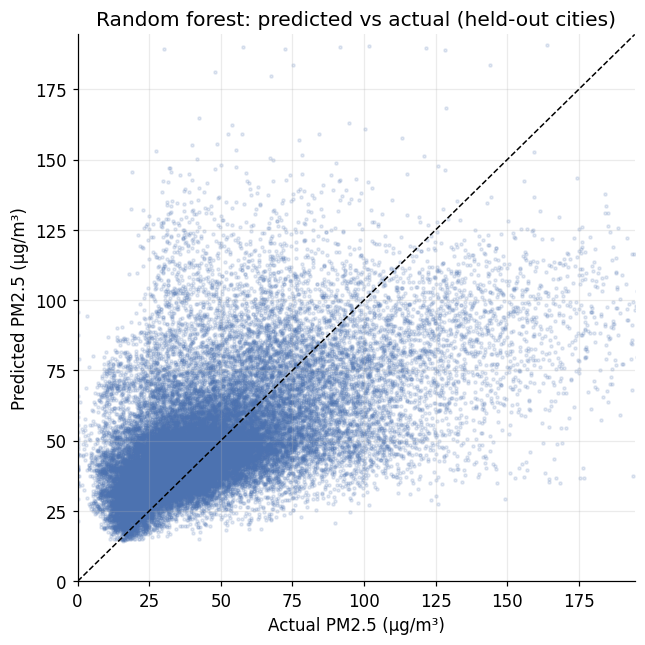

In [19]:
# Predicted vs actual for the better model.
best = max(preds, key=lambda k: r2_score(y, preds[k]))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, preds[best], s=4, alpha=0.15, color="#4C72B0")
lims = [0, np.nanpercentile(y, 99.5)]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual PM2.5 (µg/m³)"); ax.set_ylabel("Predicted PM2.5 (µg/m³)")
ax.set_title(f"{best}: predicted vs actual (held-out cities)")
plt.tight_layout(); plt.show()

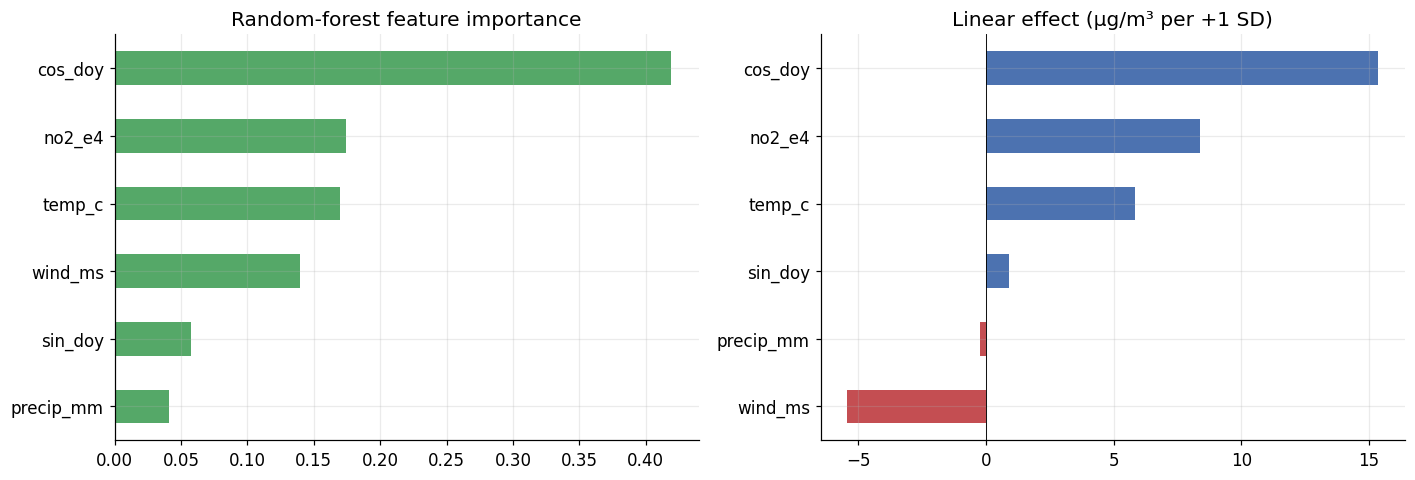

Standardized linear coefficients (effect of a +1 SD change):
no2_e4        8.36
temp_c        5.83
wind_ms      -5.43
precip_mm    -0.24
sin_doy       0.92
cos_doy      15.35


In [20]:
# What drives the prediction? RF importance + linear standardized coefficients.
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=20, n_jobs=-1,
                           random_state=0).fit(X, y)
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

lin = make_pipeline(StandardScaler(), LinearRegression()).fit(X, y)
coef = pd.Series(lin.named_steps["linearregression"].coef_, index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
imp.plot.barh(ax=axes[0], color="#55A868")
axes[0].set_title("Random-forest feature importance")
coef.sort_values().plot.barh(ax=axes[1],
    color=["#C44E52" if v < 0 else "#4C72B0" for v in coef.sort_values()])
axes[1].axvline(0, color="k", lw=0.6)
axes[1].set_title("Linear effect (µg/m³ per +1 SD)")
plt.tight_layout(); plt.show()

print("Standardized linear coefficients (effect of a +1 SD change):")
print(coef.round(2).to_string())

**Quantifying the dispersion effect.** The standardized coefficients are read directly: a `wind_ms` coefficient of, say, −3 means *a one-standard-deviation increase in wind is associated with a 3 µg/m³ drop in PM2.5, holding NO₂, temperature, rain and season fixed.* Negative wind and precipitation coefficients are the dispersion effect made numeric — the model confirming that the same emissions produce less particulate when the air is moving and being rained on. NO₂ being the largest positive driver confirms combustion is the dominant predictor, as expected.

*(Temperature's coefficient is partly a season proxy — interpret it alongside the sin/cos day-of-year terms, not in isolation.)*

In [21]:
# Plain-language summary for the writeup.
print(f"Best model: {best}")
print(f"Cross-validated R² (held-out cities): {r2_score(y, preds[best]):.2f}")
print(f"Typical error (MAE): ±{mean_absolute_error(y, preds[best]):.0f} µg/m³")
print(f"\nDispersion effect (linear, per +1 SD):")
print(f"  wind:   {coef['wind_ms']:+.1f} µg/m³")
print(f"  precip: {coef['precip_mm']:+.1f} µg/m³")
print(f"Dominant driver: {imp.idxmax()} (importance {imp.max():.2f})")

Best model: Random forest
Cross-validated R² (held-out cities): 0.31
Typical error (MAE): ±19 µg/m³

Dispersion effect (linear, per +1 SD):
  wind:   -5.4 µg/m³
  precip: -0.2 µg/m³
Dominant driver: cos_doy (importance 0.42)


## Part C — takeaways

- NO₂ + weather + season predict PM2.5 with meaningful skill **even on cities the model never trained on**, confirming the relationships generalise rather than being memorised city baselines.
- **NO₂ is the dominant predictor**, consistent with combustion being the primary particulate source.
- **Wind and rain carry negative coefficients** — the dispersion effect, now quantified in µg/m³ rather than just asserted.
- This is associational. To move toward causal attribution you'd need a counterfactual design or controlled meteorological normalisation — a natural extension, noted in limitations.

> The trained model is also what powers the **interactive forecast tab** in the Streamlit dashboard (`app.py`), where moving the wind/rain sliders shows this dispersion effect live.

---
# Part D — Export figures 

Saves every key visualization to `visualizations/`.

saved visualizations\01_coverage.png
saved visualizations\02_city_rankings.png
saved visualizations\03_seasonal_cycle.png
saved visualizations\04_pm25_heatmap.png
saved visualizations\05_covid_anomaly.png
saved visualizations\06_weather_correlation.png
saved visualizations\07_model_pred_vs_actual.png
saved visualizations\08_feature_importance.png

Figures written to D:\NMC\AirVision - 2026\visualizations


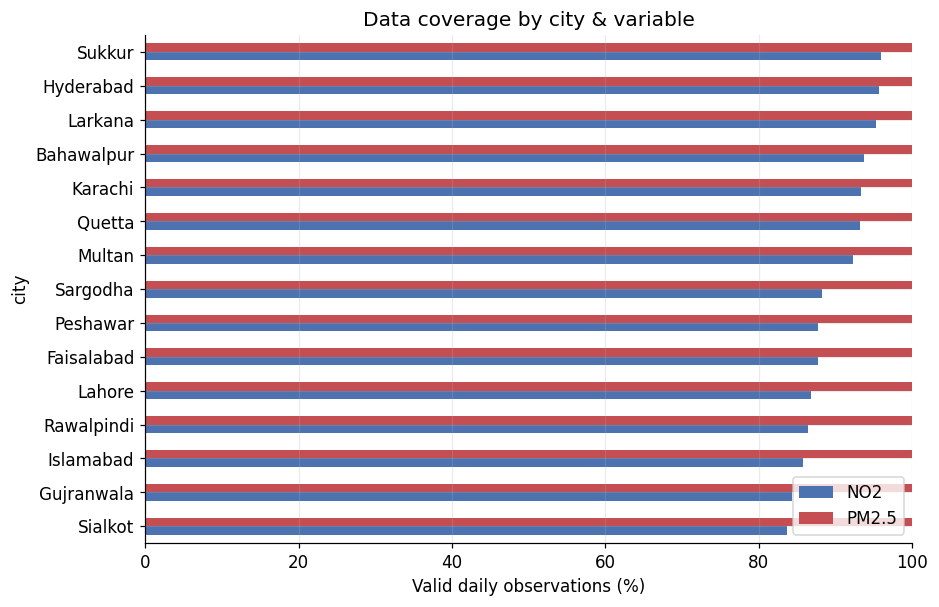

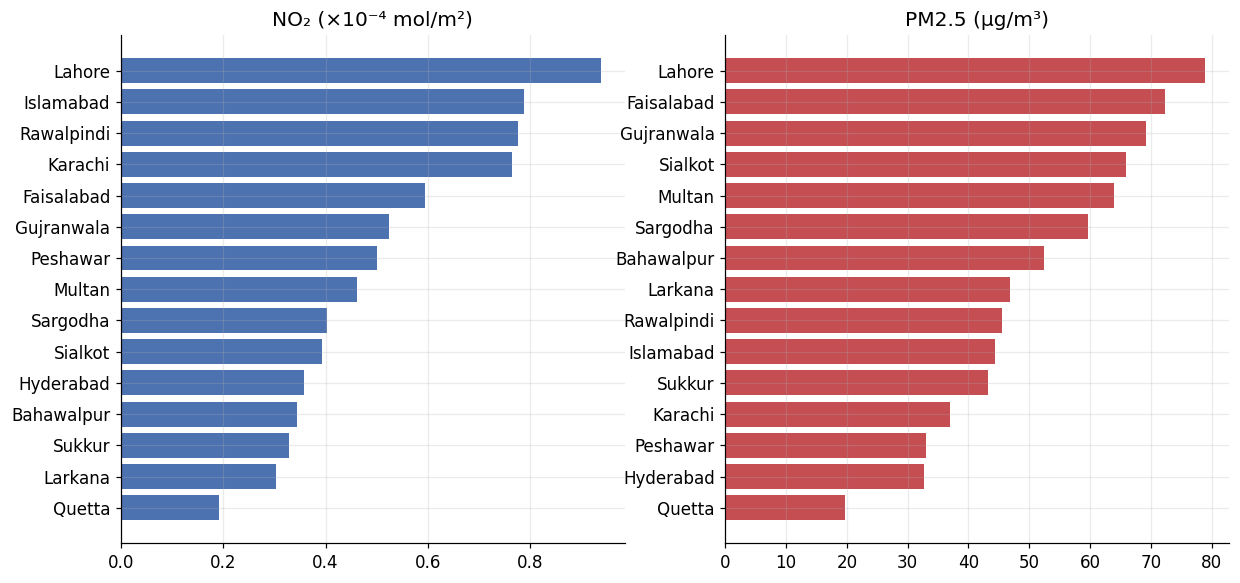

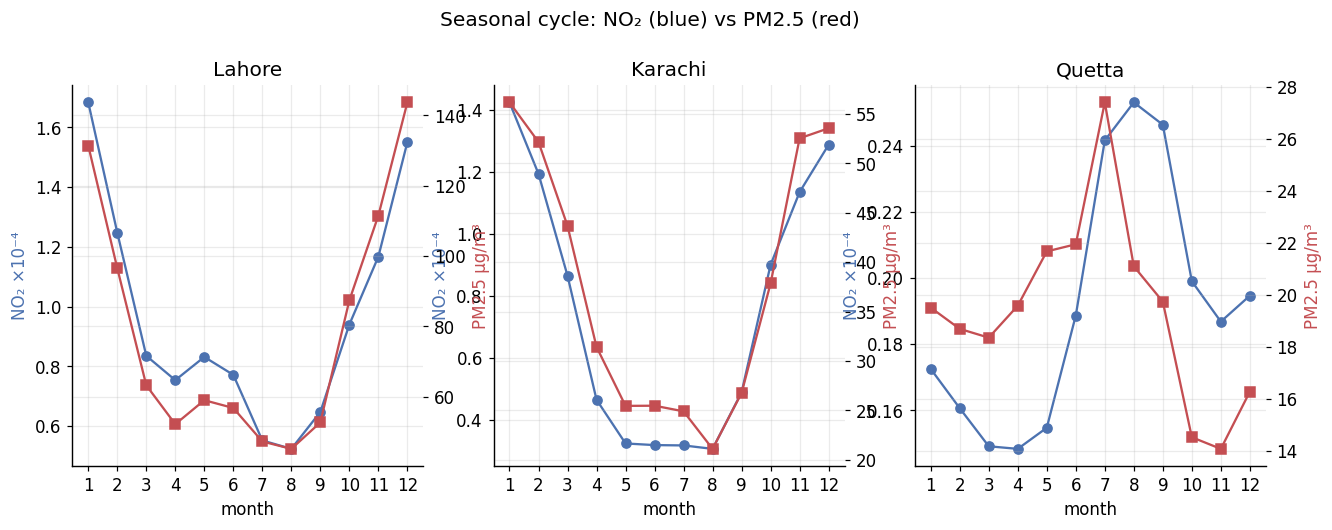

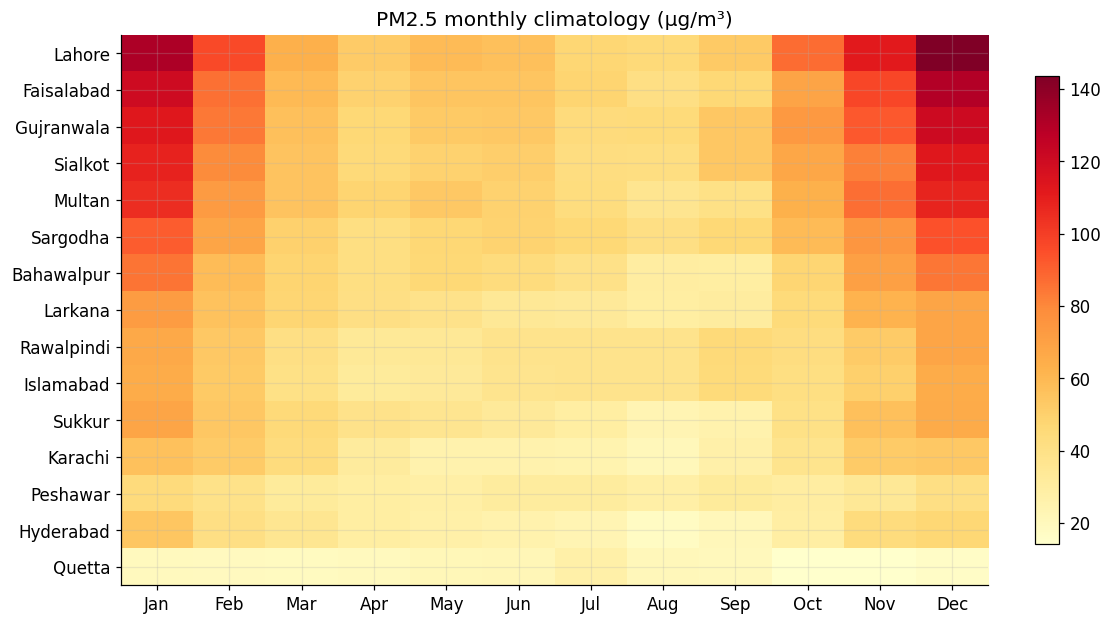

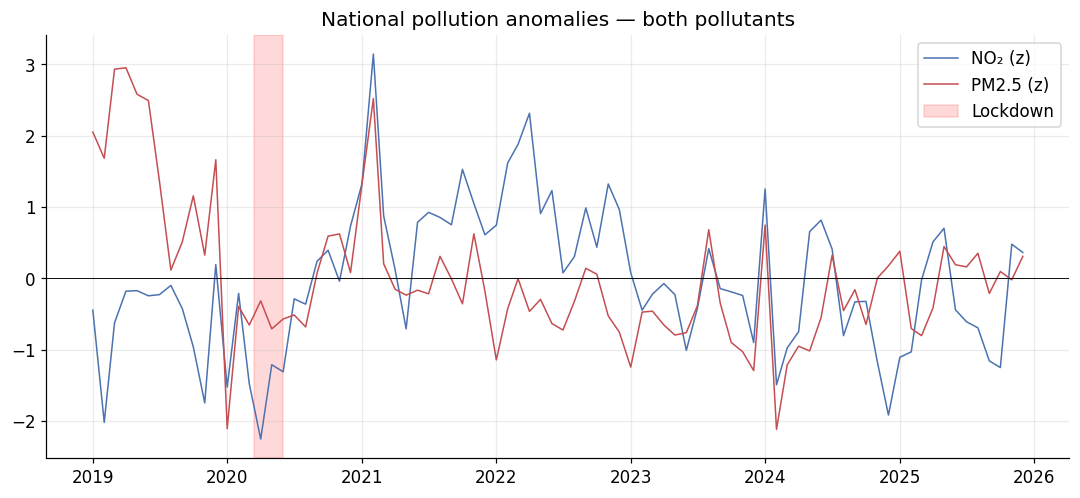

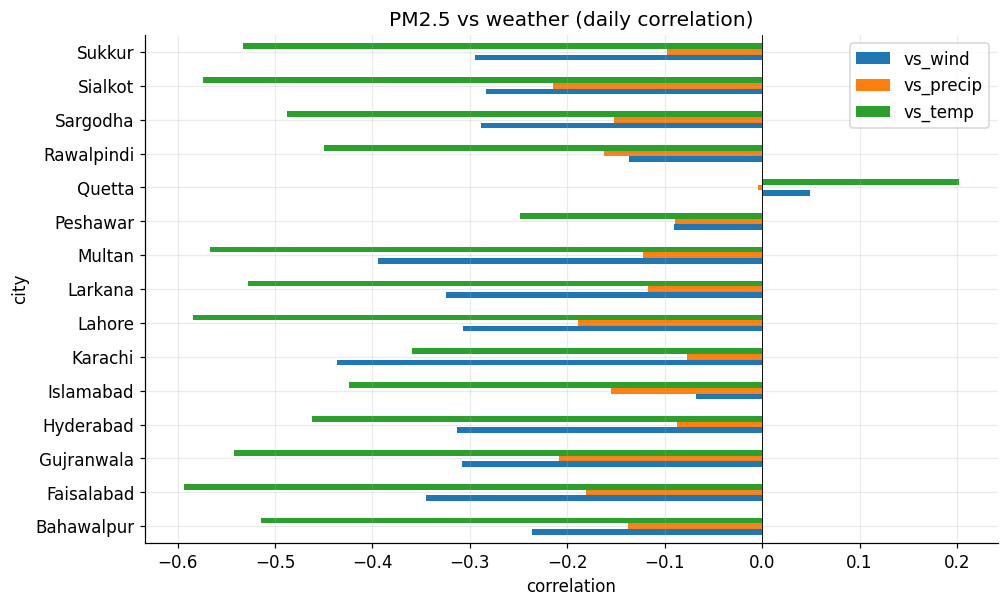

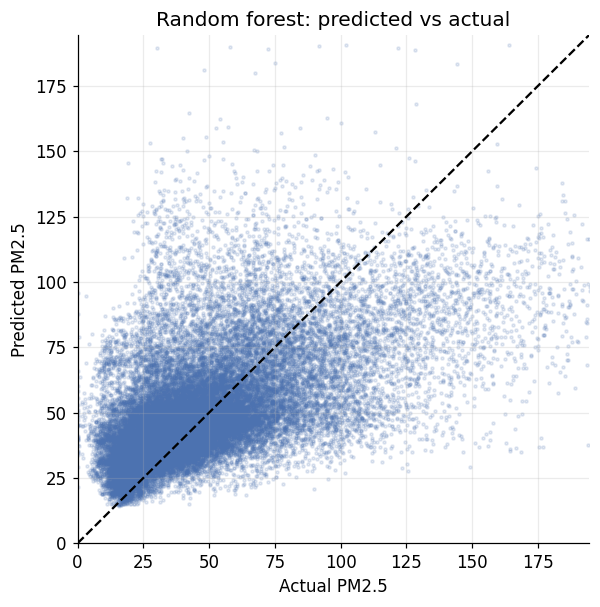

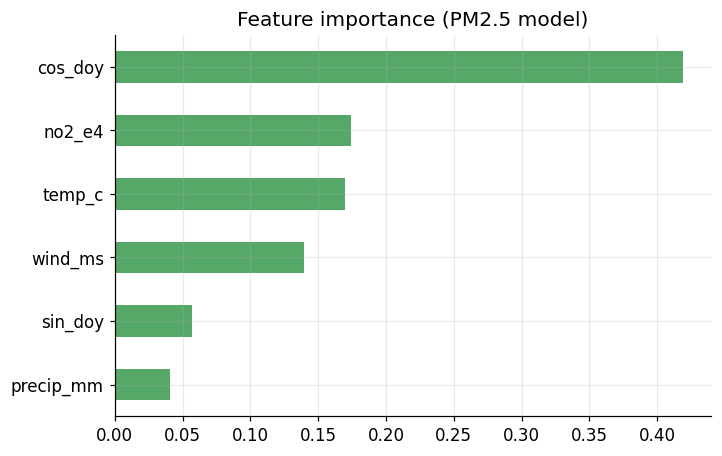

In [22]:
from pathlib import Path
VIZ = Path("visualizations"); VIZ.mkdir(exist_ok=True)

def _save(fig, name):
    fig.savefig(VIZ / name, bbox_inches="tight", dpi=120)
    print("saved", VIZ / name)

# 1. Coverage
_cov = pd.DataFrame({
    "NO2":   daily.groupby("city")["no2"].apply(lambda s: (1-s.isna().mean())*100),
    "PM2.5": daily.groupby("city")["pm25"].apply(lambda s: (1-s.isna().mean())*100)})
_cov = _cov.loc[_cov["NO2"].sort_values().index]
fig, ax = plt.subplots(figsize=(9,6)); _cov.plot.barh(ax=ax, color=["#4C72B0","#C44E52"])
ax.set_xlabel("Valid daily observations (%)"); ax.set_xlim(0,100); ax.set_title("Data coverage by city & variable")
_save(fig, "01_coverage.png")

# 2. City rankings (NO2 vs PM2.5)
_rank = pd.DataFrame({"NO2_e4": daily.groupby("city")["no2_e4"].mean(),
                      "PM2.5":  daily.groupby("city")["pm25"].mean()})
fig, axes = plt.subplots(1,2, figsize=(13,6))
_r1 = _rank.sort_values("NO2_e4"); axes[0].barh(_r1.index,_r1["NO2_e4"],color="#4C72B0"); axes[0].set_title("NO₂ (×10⁻⁴ mol/m²)")
_r2 = _rank.sort_values("PM2.5");  axes[1].barh(_r2.index,_r2["PM2.5"], color="#C44E52"); axes[1].set_title("PM2.5 (µg/m³)")
_save(fig, "02_city_rankings.png")

# 3. Seasonal cycle overlay
_clim = (daily[daily["year"].isin(COMPLETE_YRS)].groupby(["city","month"])[["no2_e4","pm25"]].mean().reset_index())
fig, axes = plt.subplots(1,3, figsize=(14,4.5))
for ax, c in zip(axes, ["Lahore","Karachi","Quetta"]):
    g=_clim[_clim.city==c]; ax2=ax.twinx()
    ax.plot(g["month"],g["no2_e4"],"o-",color="#4C72B0"); ax2.plot(g["month"],g["pm25"],"s-",color="#C44E52")
    ax.set_title(c); ax.set_xticks(range(1,13)); ax.set_xlabel("month")
    ax.set_ylabel("NO₂ ×10⁻⁴",color="#4C72B0"); ax2.set_ylabel("PM2.5 µg/m³",color="#C44E52")
fig.suptitle("Seasonal cycle: NO₂ (blue) vs PM2.5 (red)", y=1.03)
_save(fig, "03_seasonal_cycle.png")

# 4. PM2.5 climatology heatmap
_piv=_clim.pivot(index="city",columns="month",values="pm25"); _piv=_piv.loc[_piv.mean(axis=1).sort_values(ascending=False).index]
fig,ax=plt.subplots(figsize=(11,6.5)); im=ax.imshow(_piv.values,aspect="auto",cmap="YlOrRd")
ax.set_xticks(range(12)); ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_yticks(range(len(_piv.index))); ax.set_yticklabels(_piv.index); ax.set_title("PM2.5 monthly climatology (µg/m³)")
plt.colorbar(im,ax=ax,fraction=0.025); _save(fig, "04_pm25_heatmap.png")

# 5. COVID anomaly
def _natanom(col):
    cl=daily[daily.year.isin(COMPLETE_YRS)].groupby(["city","month"])[col].transform("mean")
    t=daily.assign(a=daily[col]-cl)
    return t.groupby(["city",pd.Grouper(key="date",freq="MS")])["a"].mean().reset_index().groupby("date")["a"].mean()
fig,ax=plt.subplots(figsize=(12,5))
for col,color,lab in [("no2_e4","#4C72B0","NO₂"),("pm25","#C44E52","PM2.5")]:
    s=_natanom(col); ax.plot(s.index,s.values/s.std(),color=color,lw=1,label=f"{lab} (z)")
ax.axhline(0,color="k",lw=.6); ax.axvspan(pd.Timestamp("2020-03-15"),pd.Timestamp("2020-06-01"),color="red",alpha=.15,label="Lockdown")
ax.set_title("National pollution anomalies — both pollutants"); ax.legend(); _save(fig, "05_covid_anomaly.png")

# 6. Weather correlation
_rows=[]
for c in CITIES:
    g=daily[daily.city==c][["pm25","wind_ms","precip_mm","temp_c"]].dropna()
    if len(g)>100: _rows.append({"city":c,"vs_wind":g.pm25.corr(g.wind_ms),"vs_precip":g.pm25.corr(g.precip_mm),"vs_temp":g.pm25.corr(g.temp_c)})
_wc=pd.DataFrame(_rows).set_index("city")
fig,ax=plt.subplots(figsize=(10,6)); _wc[["vs_wind","vs_precip","vs_temp"]].plot.barh(ax=ax); ax.axvline(0,color="k",lw=.6)
ax.set_title("PM2.5 vs weather (daily correlation)"); ax.set_xlabel("correlation"); _save(fig, "06_weather_correlation.png")

# 7 & 8 require the model from Part C (preds, best, rf, imp already defined there).
try:
    fig,ax=plt.subplots(figsize=(6,6)); ax.scatter(y,preds[best],s=4,alpha=.15,color="#4C72B0")
    _l=[0,np.nanpercentile(y,99.5)]; ax.plot(_l,_l,"k--"); ax.set_xlim(_l); ax.set_ylim(_l)
    ax.set_xlabel("Actual PM2.5"); ax.set_ylabel("Predicted PM2.5"); ax.set_title(f"{best}: predicted vs actual")
    _save(fig, "07_model_pred_vs_actual.png")
    fig,ax=plt.subplots(figsize=(7,4.5)); imp.plot.barh(ax=ax,color="#55A868"); ax.set_title("Feature importance (PM2.5 model)")
    _save(fig, "08_feature_importance.png")
except NameError:
    print("Run Part C first to also export the model figures (07, 08).")

print("\nFigures written to", VIZ.resolve())

## B8. Limitations & next steps

**Limitations:**
- **NO₂ is a measured combustion proxy; PM2.5 is *modelled* (CAMS, ~40 km), not a ground measurement; weather is reanalysis.** Each is interpreted accordingly.
- **Sparse ground truth** in Pakistan — values checked against physical plausibility and cross-variable consistency, not a dense reference network.
- **NO₂ missing-not-at-random** — cloud/fog removes the foggiest winter days, so NO₂ winter peaks are conservative. A single PM2.5 day (2023-05-12) is absent due to a corrupt source image and kept as `NaN`.
- **Short trend window & partial 2026** (excluded from annual stats).
- **Correlation ≠ causation** in the weather analysis — wind/rain associations are suggestive, not a controlled attribution.

**Next steps:**
- Validate against any available ground/citizen PM2.5 sensors (e.g. OpenAQ) for the cities that have them.
- Build a regression/ML model predicting PM2.5 from NO₂ + weather to quantify the dispersion effect.
- Ship an interactive dashboard on the daily/weekly/monthly layers.